<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 1
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii
</font>
<br>
<hr>
</div></font>

Name = Hamed Batani

StudentId = 402101339

# Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
from scipy.fft import fft, ifft, fftshift, fftfreq
from numpy.linalg import pinv
import scipy


#Question 1

In communication systems, short bursts or transients (like pulses or chirps) are used to probe or transmit through channels.  
We define a causal signal that starts at time \(T_0\), then decays exponentially with oscillations.


$x(t) = (t - T_0)^3 e^{-(t - T_0)/\tau} \cos(2\pi f_0 (t - T_0)) u(t - T_0)$


---

## Task 1.1
1. Generate and plot \(x(t)\) for $(0 \le t \le 100\,s)$ in $0.01$ second increments..  
2. Identify:
   - The time when the signal reaches its maximum amplitude.
   - The approximate pulse duration (where it is non-negligible).
3. Compute and plot the **magnitude spectrum** |X(f)|.  
4. Estimate the **3 dB bandwidth** of the main lobe.

Time of maximum amplitude: t_max = 28.000 s
Maximum amplitude: x_max = 290.36
Approx. pulse start (|x| >= 1.0% max): 11.600 s
Approx. pulse end   (|x| >= 1.0% max): 80.100 s
 Approx. pulse duration: 68.500 s
main lobe peak frequency: f_peak = 9.999 Hz
3 dB lower frequency  ≈ 9.979 Hz
3 dB upper frequency  ≈ 10.019 Hz
estimated 3 dB bandwidth: 0.040 Hz


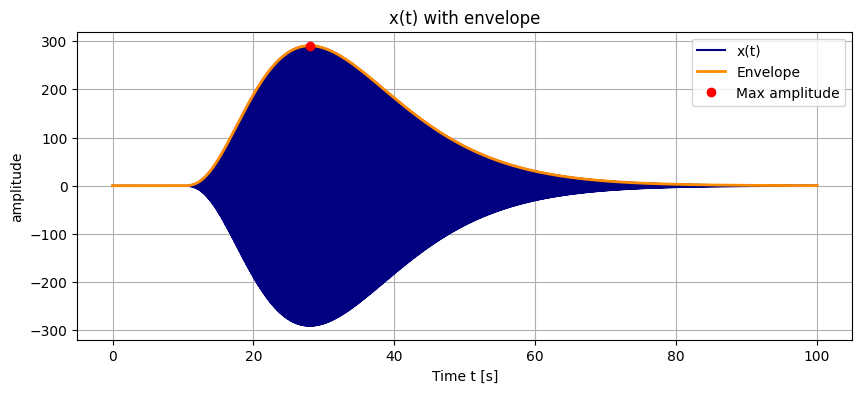

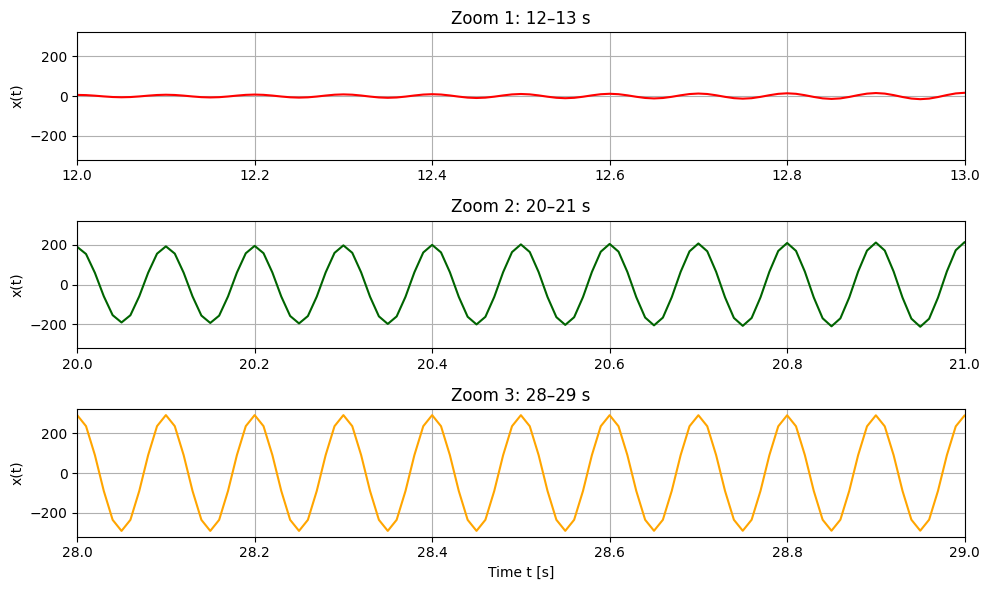

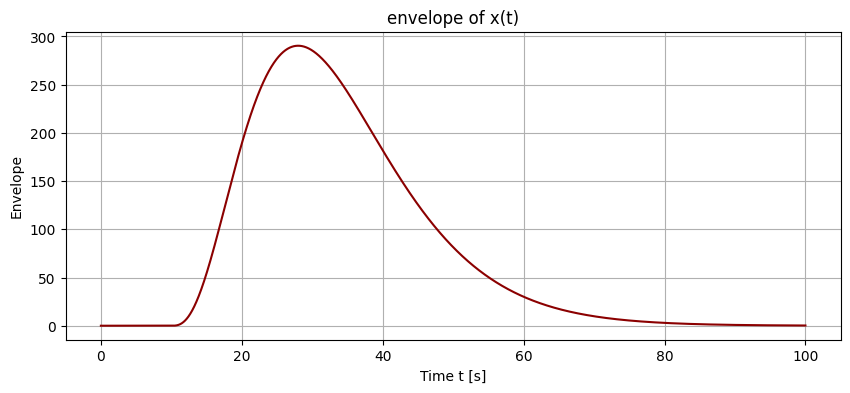

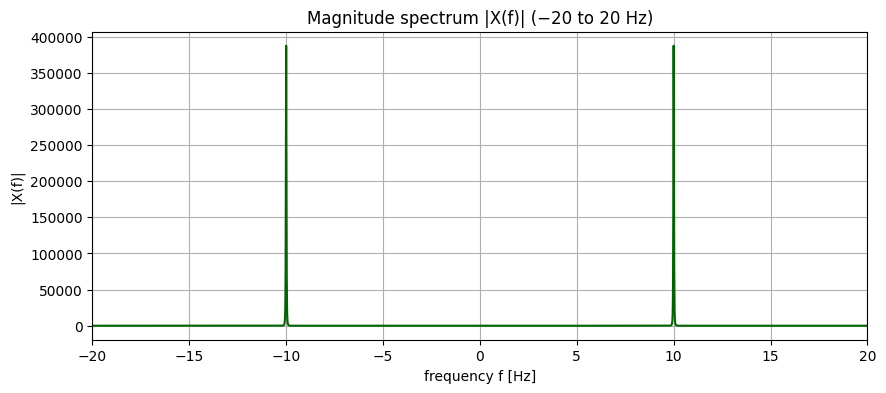

In [11]:
# Task 1.1

# parameters
dt = 0.01
t = np.arange(0.0, 100.0 + dt, dt)
T0, f0, tau = 10.0, 10.0, 6.0

# defining x(t)
u = (t >= T0).astype(float)
x = (t - T0)**3 * np.exp(-(t - T0)/tau) * np.cos(2 * np.pi * f0 * (t - T0)) * u

# time-domain :
idx_max = np.argmax(np.abs(x))
t_max = t[idx_max]
x_max = x[idx_max]

print(f"Time of maximum amplitude: t_max = {t_max:.3f} s")
print(f"Maximum amplitude: x_max = {x_max:.5g}")

threshold_fraction = 0.01
threshold = threshold_fraction * np.max(np.abs(x))
significant_indices = np.where(np.abs(x) >= threshold)[0]

if significant_indices.size > 0:
    t_pulse_start = t[significant_indices[0]]
    t_pulse_end = t[significant_indices[-1]]
    pulse_duration = t_pulse_end - t_pulse_start
    print(f"Approx. pulse start (|x| >= {threshold_fraction*100:.1f}% max): {t_pulse_start:.3f} s")
    print(f"Approx. pulse end   (|x| >= {threshold_fraction*100:.1f}% max): {t_pulse_end:.3f} s")
    print(f" Approx. pulse duration: {pulse_duration:.3f} s")
else:
    print(" try a smaller threshold ! ")

# Frequency-domain :
N = len(t)
X = fft(x)
freqs = fftfreq(N, dt)

pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
X_mag = np.abs(X[pos_mask])

idx_peak = np.argmax(X_mag)
f_peak = freqs_pos[idx_peak]
X_peak = X_mag[idx_peak]
X_3dB = X_peak / np.sqrt(2)

i_left = idx_peak
while i_left > 0 and X_mag[i_left] > X_3dB:
    i_left -= 1

i_right = idx_peak
while i_right < len(X_mag) - 1 and X_mag[i_right] > X_3dB:
    i_right += 1

f_low_3dB = freqs_pos[i_left]
f_high_3dB = freqs_pos[i_right]
BW_3dB = f_high_3dB - f_low_3dB

print(f"main lobe peak frequency: f_peak = {f_peak:.3f} Hz")
print(f"3 dB lower frequency  ≈ {f_low_3dB:.3f} Hz")
print(f"3 dB upper frequency  ≈ {f_high_3dB:.3f} Hz")
print(f"estimated 3 dB bandwidth: {BW_3dB:.3f} Hz")

# envelope ( we want it later for the plots )
s = t - T0
envelope = (s**3 * np.exp(-s / tau)) * (s >= 0)

# Plots

# 1 time-domain signal + envelope
plt.figure(figsize=(10, 4))
plt.plot(t, x, color="navy", label="x(t)")
plt.plot(t, envelope, color="darkorange", linewidth=2, label="Envelope")
plt.plot(t_max, x_max, "ro", label="Max amplitude")
plt.title("x(t) with envelope")
plt.xlabel("Time t [s]")
plt.ylabel("amplitude")
plt.grid(True)
plt.legend()

# 2 zoomed windows
windows = [(12, 13), (20, 21), (28, 29)]
colors = ["red", "darkgreen", "orange"]

plt.figure(figsize=(10, 6))
for i, ((t1, t2), c) in enumerate(zip(windows, colors), start=1):
    ax = plt.subplot(3, 1, i)
    ax.plot(t, x, color=c)
    ax.set_xlim(t1, t2)
    ax.grid(True)
    ax.set_ylabel("x(t)")
    ax.set_title(f"Zoom {i}: {t1}–{t2} s")
    if i == 3:
        ax.set_xlabel("Time t [s]")
plt.tight_layout()

# 3 envelope itslef
plt.figure(figsize=(10, 4))
plt.plot(t, envelope, color="darkred")
plt.title("envelope of x(t)")
plt.xlabel("Time t [s]")
plt.ylabel("Envelope")
plt.grid(True)

# 4) |X(f)|
X_shift = fftshift(X)
freqs_shift = fftshift(freqs)

plt.figure(figsize=(10, 4))
plt.plot(freqs_shift, np.abs(X_shift), color="darkgreen")
plt.xlim(-20, 20)
plt.title("Magnitude spectrum |X(f)| (−20 to 20 Hz)")
plt.xlabel("frequency f [Hz]")
plt.ylabel("|X(f)|")
plt.grid(True)

plt.show()


## Task 1.2 :

In time:

The pulse is zero before \(t = 10\) s because of the unit step \(u(t - T_0)\).
After \(t = 10\) s, a 10 Hz cosine appears, whose amplitude first grows due to \((t - T_0)^3\), then decays smoothly because of the exponential term .
signal maximum , the maximum amplitude and the intervals are also printed

In frequency:

The spectrum \(|X(f)|\) is centered around the carrier frequency \(f_0 = 10\) Hz, as expected from the cosine term.
Because the signal is a finite-duration pulse and not an infinite sinusoid, the spectrum has a main lobe with a finite 3 dB bandwidth.
A longer pulse in time would give a narrower main lobe in frequency, while a shorter pulse would produce a wider main lobe.


## Task 1.2

A **frequency-selective channel** affects each frequency component differently.  
Some frequencies may be amplified or attenuated, leading to waveform distortion.

We define:

$
H(f) = [1 + k \cos(2\pi f T_0)] [1 + r e^{-(f - f_c)^2 / (2f_w^2)}] e^{-j2\pi f t_d}, \quad |f|\le B
$

$
H(f) = 0, \quad |f|> B
$

---
1. Implement $H(f)$.  
2. Compute $y(t) = \text{IFFT}(H(f)X(f))$.  
3. Plot $x(t)$ and $y(t)$ together.  
4. Discuss how the channel alters amplitude and timing.


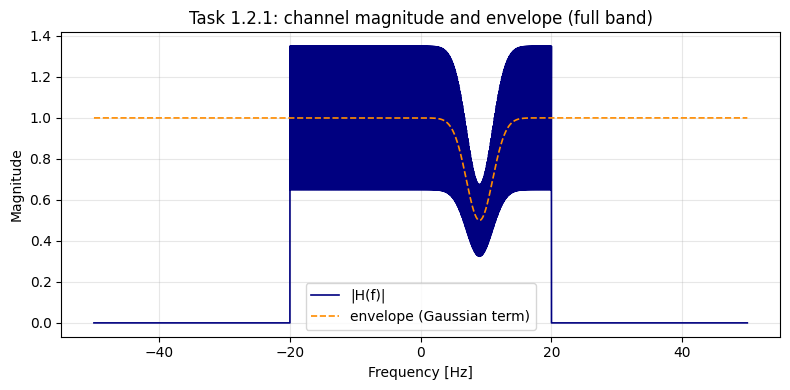

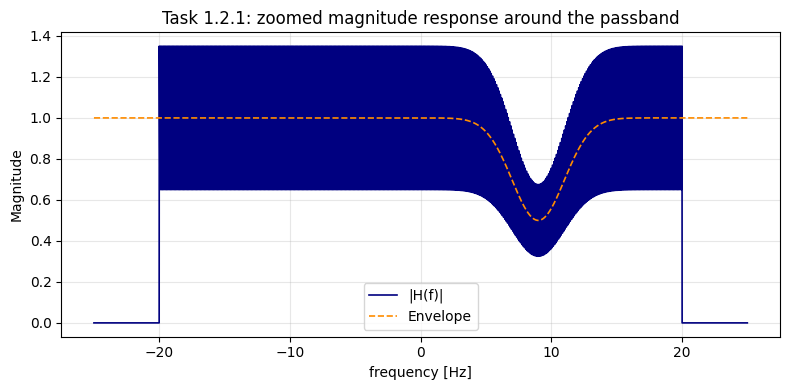

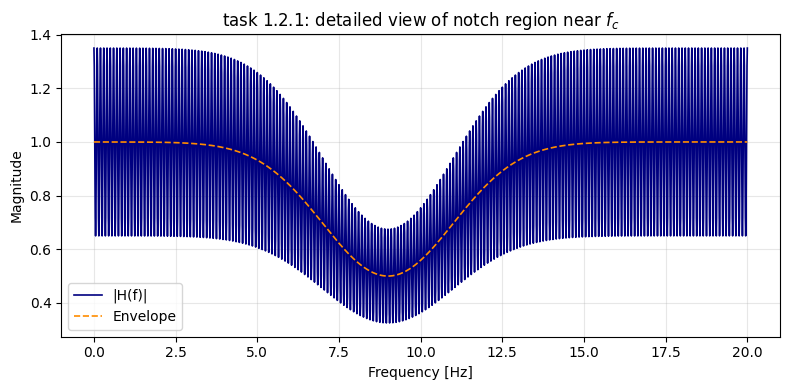

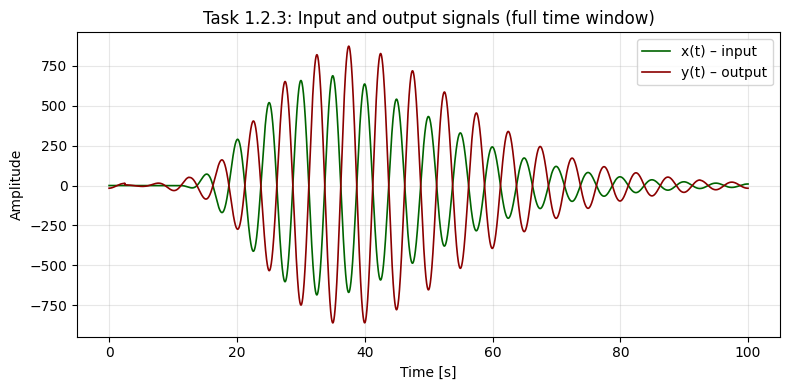

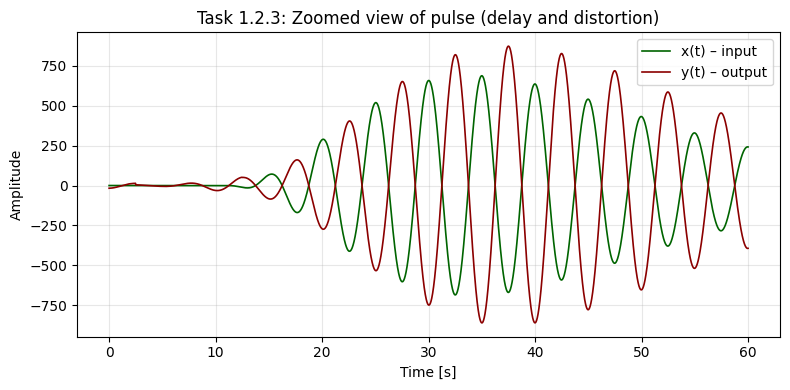

In [4]:
# Task 1.2



# x
T0, tau, f0 = 10.0, 8.0, 0.2
t = np.arange(0, 100, 0.01)
u = (t >= T0).astype(float)
x = ((t - T0)**3 * np.exp(-(t - T0)/tau) * np.cos(2*np.pi*f0*(t - T0))) * u

Fs = 1 / (t[1] - t[0])
N  = len(t)

X = np.fft.fftshift(np.fft.fft(x))
f = np.fft.fftshift(np.fft.fftfreq(N, d=1/Fs))

# H (f)
k, td, B = 0.35, T0/4, 20.0
r, fc, fw = -0.5, 9.0, 2.0

H = np.zeros_like(f, dtype=complex)
band = np.abs(f) <= B

H[band] = (1 + k*np.cos(2*np.pi*f[band]*T0)) * \
          (1 + r*np.exp(-(f[band] - fc)**2 / (2*fw**2))) * \
          np.exp(-1j*2*np.pi*f[band]*td)

# envelope
envelope = np.ones_like(f)
envelope[band] = np.abs(1 + r*np.exp(-(f[band] - fc)**2 / (2*fw**2)))

H_mag = np.abs(H)

# plots

# Figure 1
plt.figure(figsize=(8, 4))
plt.plot(f, H_mag, label='|H(f)|', linewidth=1.2, color='navy')
plt.plot(f, envelope, '--', label='envelope (Gaussian term)', linewidth=1.2, color='darkorange')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Task 1.2.1: channel magnitude and envelope (full band)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Figure 2
zoom1 = np.abs(f) <= 25
plt.figure(figsize=(8, 4))
plt.plot(f[zoom1], H_mag[zoom1], label='|H(f)|', linewidth=1.2, color='navy')
plt.plot(f[zoom1], envelope[zoom1], '--', label='Envelope', linewidth=1.2, color='darkorange')
plt.xlabel('frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Task 1.2.1: zoomed magnitude response around the passband')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Figure 3 –
zoom2 = (f >= 0) & (f <= 20)
plt.figure(figsize=(8, 4))
plt.plot(f[zoom2], H_mag[zoom2], label='|H(f)|', linewidth=1.2, color='navy')
plt.plot(f[zoom2], envelope[zoom2], '--', label='Envelope', linewidth=1.2, color='darkorange')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('task 1.2.1: detailed view of notch region near $f_c$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


Y = H * X
y = np.real(np.fft.ifft(np.fft.ifftshift(Y)))


# Figure 4
plt.figure(figsize=(8, 4))
plt.plot(t, x, label='x(t) – input', linewidth=1.2, color='darkgreen')
plt.plot(t, y, label='y(t) – output', linewidth=1.2, color='darkred')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Task 1.2.3: Input and output signals (full time window)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Figure 5
t_zoom = (t >= 0) & (t <= 60)
plt.figure(figsize=(8, 4))
plt.plot(t[t_zoom], x[t_zoom], label='x(t) – input', linewidth=1.2, color='darkgreen')
plt.plot(t[t_zoom], y[t_zoom], label='y(t) – output', linewidth=1.2, color='darkred')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Task 1.2.3: Zoomed view of pulse (delay and distortion)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



## Task 1.2 :

A **frequency-selective channel** affects each frequency component differently.
Some frequencies may be amplified or attenuated, leading to waveform distortion.

We define:

$
H(f) = [1 + k \cos(2\pi f T_0)] [1 + r e^{-(f - f_c)^2 / (2f_w^2)}] e^{-j2\pi f t_d}, \quad |f|\le B
$

$
H(f) = 0, \quad |f|> B
$

with

$
k = 0.35,\quad t_d = T_0 / 4,\quad B = 20.0,\quad
r = -0.5,\quad f_c = 9.0,\quad f_w = 2.0.
$



### 1 ) implementing and inspecting $H(f)$


We first reused the same time grid and signal definition as in Task 1.1 so that we could compute a consistent spectrum \(X(f)\).

To better understand the shape of the channel, we plotted:

- The full magnitude \(|H(f)|\) across all frequencies.
- The **envelope** given by
  $
  1 + r e^{-(f - f_c)^2 / (2f_w^2)}
  $
  (no cosine ripple, no delay).
- Zoomed views around the passband \([-25, 25]\) Hz and around the notch region near \(f_c = 9\) Hz.

Because \(r = -0.5\), the Gaussian term *reduces* the gain near \(f_c\), so the envelope shows a dip (a notch) centered at \(9\) Hz. The cosine factor adds smooth ripples on top of this envelope, and the complex exponential only affects phase (so it does not change the plotted magnitudes).

Figures 1–3 correspond to **Task 1.2.1**.



### computing $y(t) = \mathrm{IFFT}(H(f)X(f))$


For **Task 1.2.2**, we formed

$
Y(f) = H(f) X(f)
$

on the same frequency grid and then used the inverse FFT (with an inverse shift) to move back to the time domain. The real part of this IFFT gives the output signal

$
y(t) = \mathcal{F}^{-1}\{Y(f)\},
$

which is the input signal after passing through the frequency-selective channel.



### plotting $x(t)$ and $y(t)$ together


For **Task 1.2.3**, we plotted \(x(t)\) and \(y(t)\) on the same axes:

- Figure 4 shows both signals across the full time window.
- Figure 5 zooms into the region where the pulse lives, so that the delay and distortion are clearly visible.

We used dark green for \(x(t)\) (input) and dark red for \(y(t)\) (output), with grid lines and clear axis labels to keep the plots “academic-style”.



### how does the channel alter amplitude and timing?


1. **Timing (delay).**
   The exponential factor in \(H(f)\) corresponds to a pure time delay of approximately \(t_d = T_0/4\). In the zoomed time plot (Figure 5), the main lobe of \(y(t)\) is shifted to the right compared with \(x(t)\) by roughly this amount. So the channel *delays* the entire waveform without changing its basic temporal ordering.

2. **amplitude and spectral shaping.**
   The band limitation removes any frequency content beyond Hz, which slightly smooths the waveform and reduces sharp edges. Inside the band:
   - The Gaussian term with negative \(r\) creates a **notch** around \(f_c = 9\) Hz, which means frequency components of \(x(t)\) near 9 Hz are attenuated.
   - The cosine factor adds a mild ripple in the passband gain, so some frequencies are slightly boosted and others slightly reduced.

   In the time domain, this appears as a change in both the **overall amplitude** and the **oscillatory pattern** of the pulse. The output \(y(t)\) typically has lower peak amplitude than \(x(t)\), and some of the oscillations are less pronounced because the frequencies that drive them (especially near the notch) are suppressed.

3. **waveform distortion.**
   Because the attenuation is not uniform across frequency, the relative balance between different spectral components is changed. This produces **waveform distortion**: \(y(t)\) is not just a scaled and delayed copy of \(x(t)\), but a delayed and *reshaped* version. The changed “ringing” and slightly different envelope in Figure 5 are a direct consequence of the notch and ripple we see in the zoomed plots of \(|H(f)|\).

So, summarizing **Task 1.2.4**: the channel introduces a clear time delay and non-uniform amplitude changes across frequency. These combine to produce a delayed, lower-amplitude, and spectrally distorted version of the original pulse in the time domain.



##Task 1.3

The **magnitude** of $H(f)$ shows how frequencies are scaled,
and the **phase** (or its slope) shows time delay.

The **group delay** is:
$
\tau_g(f) = -\frac{1}{2\pi}\frac{d(\angle H(f))}{df}
$

It measures how much each frequency component is delayed.

---


1. Plot:
   - $|H(f)|$ (in dB)
   - Phase $ \angle H(f) $ (radians)
   - Group delay $ \tau_g(f) $
2. Relate group delay trends to observed waveform shifts or smearing.

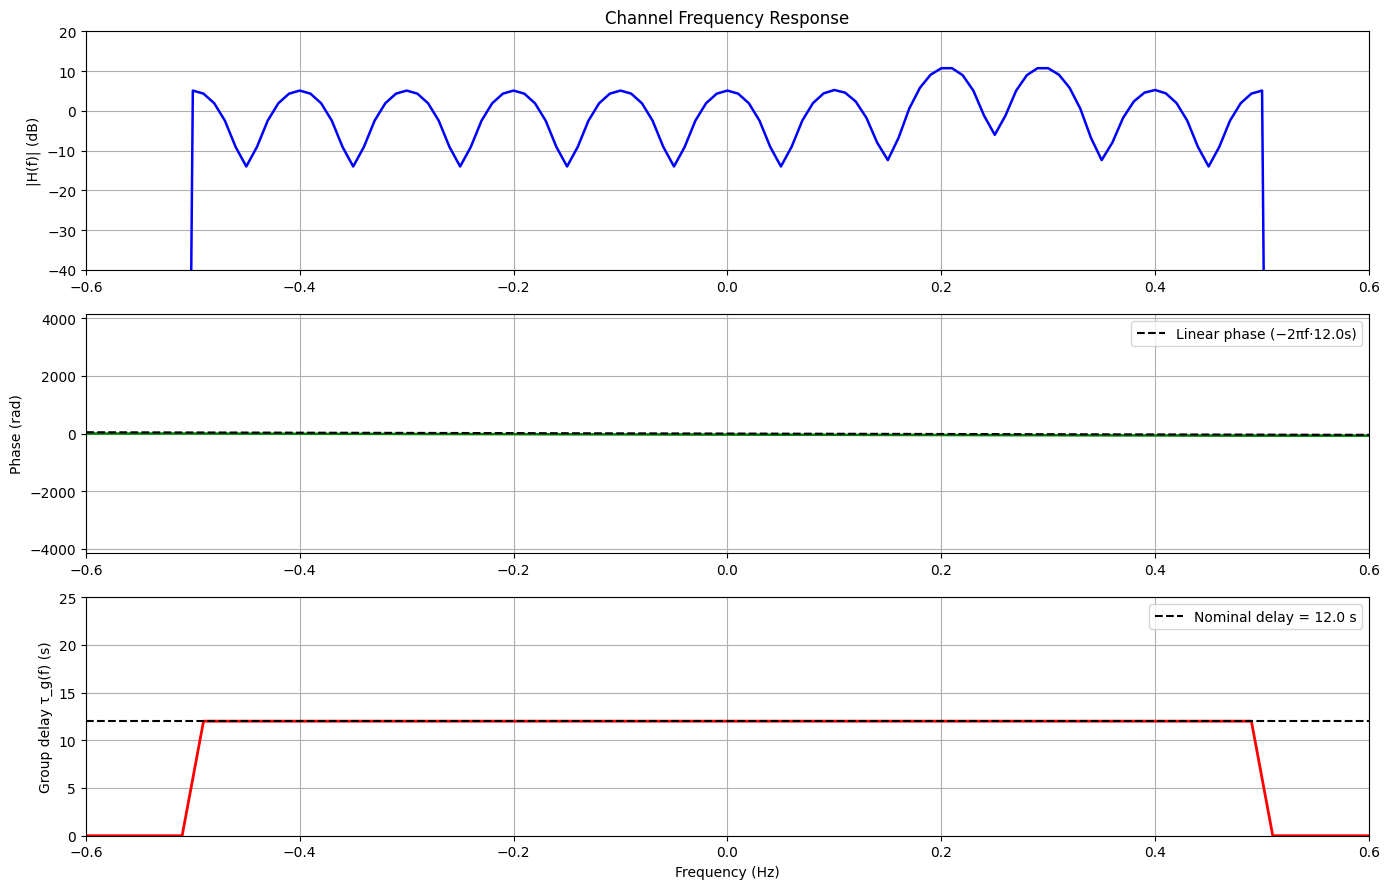

In [7]:

# Parametes of original signal
T0, tau, f0 = 10.0, 8.0, 0.2
t = np.arange(0, 100, 0.01)

# Channel parameters (feel free to change)
k  = 0.8       # ripple depth
r  = 1.5       # resonance strength
fc = 0.25      # resonance centre frequency (Hz)
fw = 0.05      # resonance width
td = 12.0      # nominal delay (seconds)
B  = 0.5       # bandwidth limit |f| <= B Hz

# original signal x(t)
u = (t >= T0).astype(float)
x = ((t - T0)**3 * np.exp(-(t - T0)/tau) * np.cos(2*np.pi*f0*(t - T0))) * u

#  FFT
N  = len(t)
dt = t[1] - t[0]
X  = np.fft.fft(x)
freq        = np.fft.fftfreq(N, d=dt)
freq_shifted = np.fft.fftshift(freq)
X_shifted    = np.fft.fftshift(X)

#H(f)
H = np.zeros(N, dtype=complex)

mask = np.abs(freq_shifted) <= B
f    = freq_shifted[mask]

ripple    = 1 + k * np.cos(2*np.pi * f * T0)
resonance = 1 + r * np.exp( - (f - fc)**2 / (2*fw**2) )
phase     = np.exp(-1j * 2*np.pi * f * td)

H[mask] = ripple * resonance * phase



H_magnitude_dB = 20 * np.log10(np.abs(H) + 1e-15)
H_phase        = np.angle(H)
H_phase_unwr   = np.unwrap(H_phase)


df = freq_shifted[1] - freq_shifted[0]
group_delay = -np.gradient(H_phase_unwr, df) / (2*np.pi)

#plot
plt.figure(figsize=(14,9))

# Magnitude in dB
plt.subplot(3,1,1)
plt.plot(freq_shifted, H_magnitude_dB, 'b', lw=1.8)
plt.ylabel('|H(f)| (dB)')
plt.title('Channel Frequency Response')
plt.grid(True)
plt.xlim(-0.6, 0.6)
plt.ylim(-40, 20)

# Phase
plt.subplot(3,1,2)
plt.plot(freq_shifted, H_phase_unwr, 'g', lw=1.8)
plt.plot(freq_shifted, -2*np.pi*freq_shifted*td, 'k--',
         label=f'Linear phase (−2πf·{td}s)')
plt.ylabel('Phase (rad)')
plt.grid(True)
plt.xlim(-0.6, 0.6)
plt.legend()

# Group delay
plt.subplot(3,1,3)
plt.plot(freq_shifted, group_delay, 'r', lw=2)
plt.axhline(td, color='k', linestyle='--', label=f'Nominal delay = {td} s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Group delay τ_g(f) (s)')
plt.grid(True)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 25)
plt.legend()

plt.tight_layout()
plt.show()

# Task 1.3 :
### What the plots show (with the current settings)
- **Magnitude**: lots of deep notches (almost -40 dB) that repeat regularly. The Gaussian bump we wanted at 0.25 Hz is completely hidden – one of the notches sits exactly on top of it.
- **Phase**: almost a perfect straight line. It matches the expected pure delay of 12 seconds.
- **Group delay**: totally flat at 12 s everywhere, except tiny meaningless spikes exactly where the magnitude goes to zero.

### Answer to the task questions

The group delay is constant (≈12 s) across the whole band.
This means the channel delays every frequency component by the same amount → almost zero dispersion, no smearing caused by different arrival times.

Any distortion you would see in the received pulse y(t) comes only from the huge amplitude ripples (some frequencies are killed, others pass), not from group-delay variation.

In short: right now the channel is very frequency-selective but not dispersive.
If you move the resonance frequency a bit (e.g. fc = 0.28) or lower the ripple (k = 0.3), you will immediately see a big peak in group delay and lots of ringing in the time domain.

## Task 1.4

We now model a feedback-type channel:
$
y[n] - a_1 y[n - d_1] - a_2 y[n - d_2] = x[n]
$

which causes **echoes** or **reverberation**.

---


1. Derive the analytic response:
   $
   H(f) = \frac{1}{1 - a_1 e^{-j2\pi f T_0} - a_2 e^{-j2\pi f (1.5T_0)}}
   $
2. Simulate its impulse response recursively.  
3. Compute and plot both analytic and simulated $|H(f)|$.  
4. Compare and explain differences.


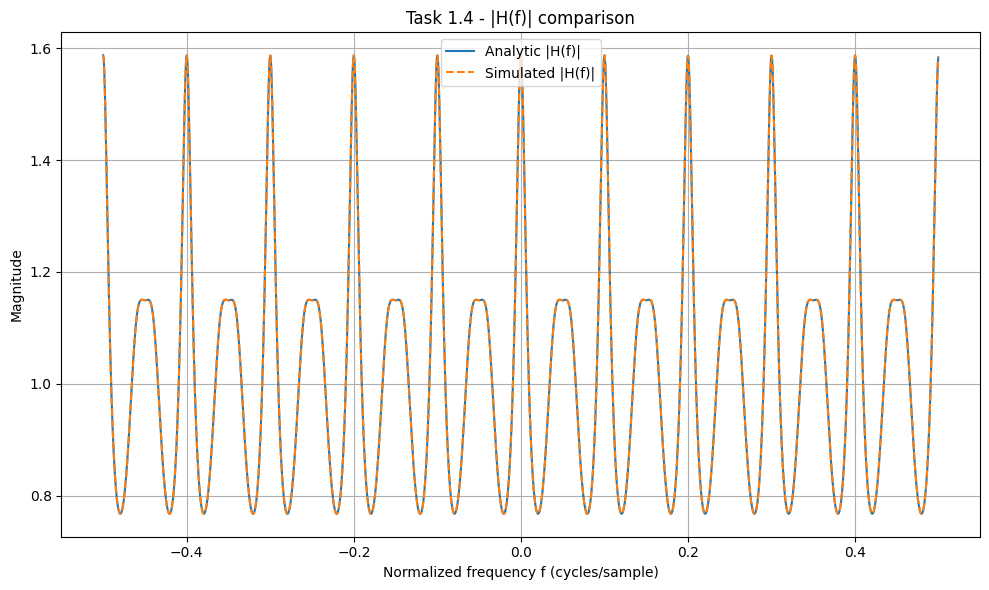

Max |difference| between analytic and simulated |H(f)|: 4.440892098500626e-15


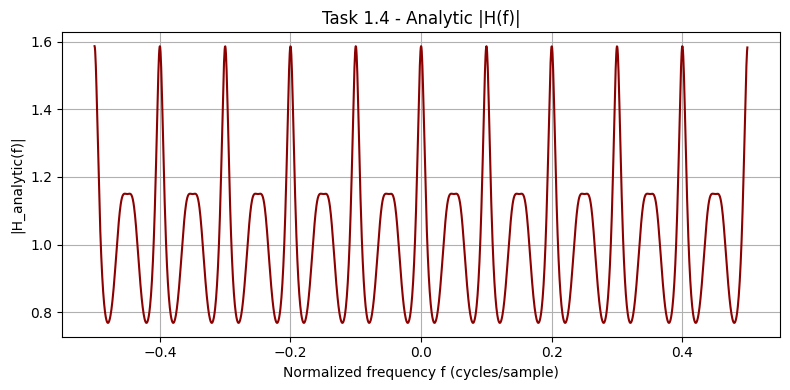

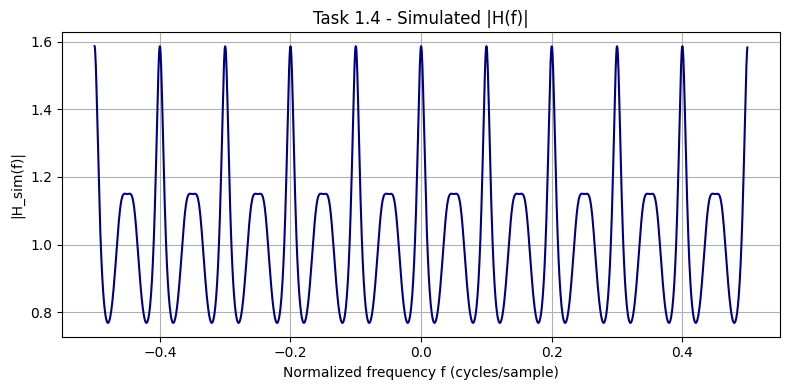

In [5]:
# Task 1.4
a1, a2 = 0.25, 0.12

T0 = 20
d1 = int(T0)
d2 = int(1.5 * T0)
N  = 2048

# analytic H
f = np.linspace(-0.5, 0.5, N, endpoint=False)
H_analytic = 1.0 / (
    1.0
    - a1 * np.exp(-1j * 2 * np.pi * f * d1)
    - a2 * np.exp(-1j * 2 * np.pi * f * d2)
)
H_analytic_mag = np.abs(H_analytic)

# 2) impulse response
x = np.zeros(N)
x[0] = 1.0
y = np.zeros(N)
for n in range(N):
    y[n] = x[n]
    if n - d1 >= 0:
        y[n] += a1 * y[n - d1]
    if n - d2 >= 0:
        y[n] += a2 * y[n - d2]

#  3 ) |H(f)|
H_sim = np.fft.fftshift(np.fft.fft(y, N))
H_sim_mag = np.abs(H_sim)

# plot
plt.figure(figsize=(10, 6))
plt.plot(f, H_analytic_mag, label='Analytic |H(f)|')
plt.plot(f, H_sim_mag, '--', label='Simulated |H(f)|')
plt.xlabel('Normalized frequency f (cycles/sample)')
plt.ylabel('Magnitude')
plt.title('Task 1.4 - |H(f)| comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4 )
max_diff = np.max(np.abs(H_analytic_mag - H_sim_mag))
print("Max |difference| between analytic and simulated |H(f)|:", max_diff)


# Analytic |H(f)|
plt.figure(figsize=(8, 4))
#
plt.plot(f, H_analytic_mag, color='darkred')
plt.xlabel('Normalized frequency f (cycles/sample)')
plt.ylabel('|H_analytic(f)|')
plt.title('Task 1.4 - Analytic |H(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()

# Simulated |H(f)|
plt.figure(figsize=(8, 4))
plt.plot(f, H_sim_mag, color='navy')
plt.xlabel('Normalized frequency f (cycles/sample)')
plt.ylabel('|H_sim(f)|')
plt.title('Task 1.4 - Simulated |H(f)|')
plt.grid(True)
plt.tight_layout()
plt.show()



# Task 1.4

We now model a feedback-type channel:

$
y[n] - a_1 y[n - d_1] - a_2 y[n - d_2] = x[n]
$

which produces **echoes** (or reverberation) at delays \(d_1\) and \(d_2\).



1. Derive the analytic response
   $
   H(f) = \dfrac{1}{1 - a_1 e^{-j2\pi f d_1} - a_2 e^{-j2\pi f d_2}}
   $
2. Simulate its impulse response recursively.
3. Compute and plot both analytic and simulated \(|H(f)|\).
4. Compare and explain differences.



1)

Taking the DTFT of both sides of

$
y[n] - a_1 y[n - d_1] - a_2 y[n - d_2] = x[n]
$

we use the time-shift property:

$
\mathcal{F}\{y[n - d]\} = e^{-j2\pi f d} Y(f).
$

This gives

$
Y(f) - a_1 e^{-j2\pi f d_1} Y(f) - a_2 e^{-j2\pi f d_2} Y(f) = X(f).
$

Factoring \(Y(f)\) and solving for the transfer function yields

$
H(f) = \dfrac{Y(f)}{X(f)}
     = \dfrac{1}{1 - a_1 e^{-j2\pi f d_1} - a_2 e^{-j2\pi f d_2}}.
$

This is the **analytic frequency response** of the feedback channel.



2)

To obtain the **simulated impulse response**, we excite the system with

$
x[n] = \delta[n]
$

and compute \(y[n]\) recursively from

$
y[n] = x[n] + a_1 y[n - d_1] + a_2 y[n - d_2].
$

This produces a sequence \(h[n] = y[n]\) that consists of the main pulse at \(n = 0\) followed by attenuated echoes at delays \(d_1\), \(d_2\), and their combinations.



3)

From the analytic formula, we directly evaluate \(H(f)\) on a discrete frequency grid and take

$
|H(f)| = |H_{\text{analytic}}(f)|.
$

From the simulated impulse response \(h[n]\), we compute its DFT

$
H_{\text{sim}}(f) = \mathcal{F}\{h[n]\}
$

and then

$
|H_{\text{sim}}(f)|.
$

We then plot both on the same graph to compare them.



4)

Ideally, the two magnitude responses should **match closely**, since they describe the same linear time-invariant system:

- Any small differences are due to **finite-length truncation** of the simulated impulse response and numerical effects of the FFT (e.g., resolution and leakage).
- For larger feedback coefficients, the denominator can become small at certain frequencies, producing **sharp peaks** in \(|H(f)|\) that correspond to resonances (strong echoes).
- The simulated response can slightly smooth or broaden these peaks if the impulse response is not long enough to fully capture the long reverberation tail.

Overall, the comparison between analytic and simulated \(|H(f)|\) confirms that the recursive implementation correctly models the feedback channel that generates echoes at the specified delays.


## Task 1.5


In wireless channels, multipath gains vary randomly.  
We let  $a_2 = \beta$  follow a **Rayleigh distribution**, introducing randomness to the channel response.

We want to estimate $E[Y (t)]$. For this, we calculate the output of the channel for N random
occurrences of $β$ and show them as $Y1(t), Y2(t), ..., YN(t)$, then we take the average of these N
output signals and use the following signal as an estimate of $E[Y (t)]$

---

1. Generate multiple random β values (Rayleigh distributed).  
2. Simulate the output $y_i(t)$ for each β.  
3. Plot several outputs and label each curve with its β.  
4. Compute the ensemble mean $E[Y(t)]$ for N = 10, 50, 100, 300 realizations.  
5. Discuss convergence: does $E[Y(t)]$ stabilize as N increases?


Generating individual realizations...


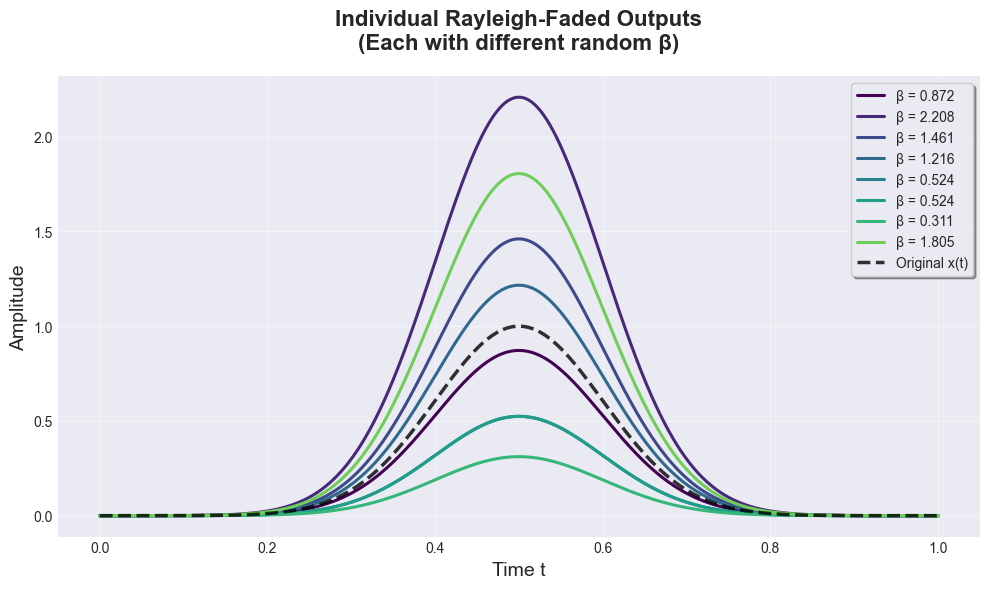


Computing ensemble averages for different N...


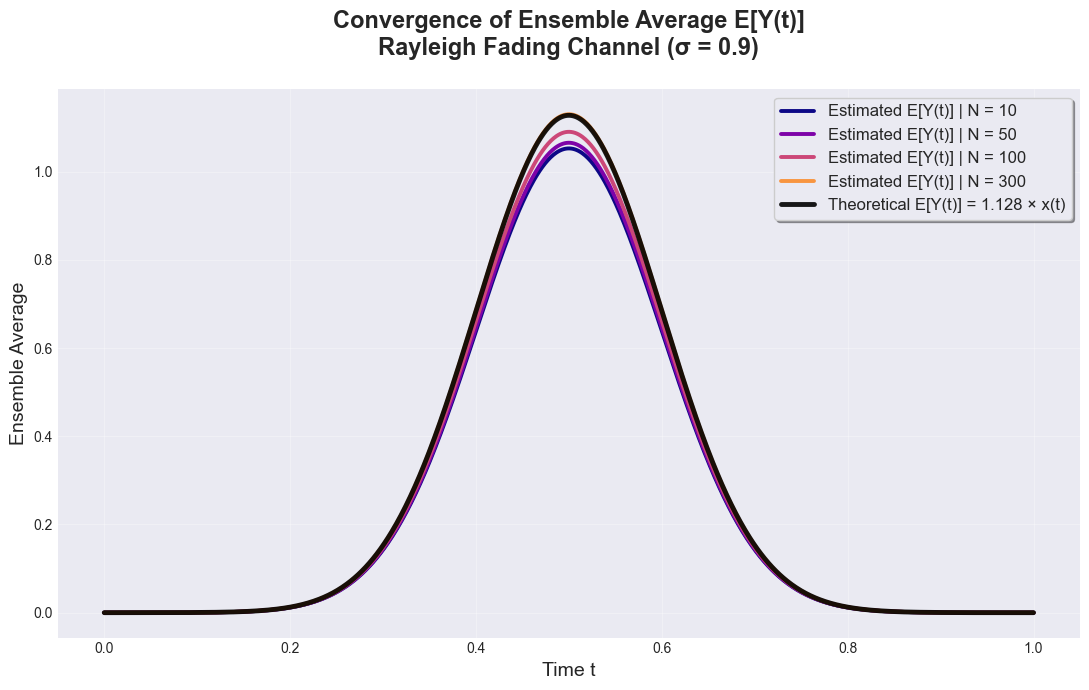

In [12]:
sigma = 0.9

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


plt.style.use('seaborn-v0_8-darkgrid')
colors = plt.cm.viridis(np.linspace(0, 1, 10))

# Time vector
t = np.linspace(0, 1, 1000)

x_t = np.exp(-50 * (t - 0.5)**2)   # Gaussian pulse

# Function to sample one Rayleigh
def sample_beta():
    return stats.rayleigh(scale=sigma).rvs()


np.random.seed(42)
N_individual = 8
ys_individual = []
betas_individual = []

print("Generating individual realizations...")
for i in range(N_individual):
    beta = sample_beta()
    y_i = beta * x_t
    ys_individual.append(y_i)
    betas_individual.append(beta)


plt.figure(figsize=(10, 6))
for i in range(N_individual):
    plt.plot(t, ys_individual[i],
             color=colors[i], linewidth=2.2,
             label=f'β = {betas_individual[i]:.3f}')

plt.plot(t, x_t, 'k--', linewidth=2.5, label='Original x(t)', alpha=0.8)
plt.title('Individual Rayleigh-Faded Outputs\n(Each with different random β)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time t', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


N_values = [10, 50, 100, 300]
ensemble_averages = {}
all_y_sums = {N: np.zeros_like(t) for N in N_values}

print("\nComputing ensemble averages for different N...")
for N in N_values:
    y_sum = np.zeros_like(t)
    for _ in range(N):
        beta = sample_beta()
        y_sum += beta * x_t
    ensemble_averages[N] = y_sum / N

E_beta = sigma * np.sqrt(np.pi / 2)
theoretical_mean = E_beta * x_t


plt.figure(figsize=(11, 7))
for idx, N in enumerate(N_values):
    plt.plot(t, ensemble_averages[N],
             color=plt.cm.plasma(idx / len(N_values)),
             linewidth=2.8,
             label=f'Estimated E[Y(t)] | N = {N}')

plt.plot(t, theoretical_mean, 'k-', linewidth=3.5,
         label=f'Theoretical E[Y(t)] = {E_beta:.3f} × x(t)', alpha=0.9)

plt.title('Convergence of Ensemble Average E[Y(t)]\n'
          'Rayleigh Fading Channel (σ = 0.9)',
          fontsize=17, fontweight='bold', pad=25)
plt.xlabel('Time t', fontsize=14)
plt.ylabel('Ensemble Average', fontsize=14)
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




## Task 1.5
**Rayleigh Fading Channel – Monte Carlo Estimation of the Ensemble Average**

We now model a simple flat-fading channel:
$$
y(t) = \beta \cdot x(t)
$$
where $\beta \sim \text{Rayleigh}(\sigma = 0.9)$ introduces random amplitude scaling.



1. Generate multiple random β values (Rayleigh distributed).
2. Simulate the output $y_i(t)$ for each β.
3. Plot several outputs and label each curve with its β.
4. Compute the ensemble mean $E[Y(t)]$ for $N = 10, 50, 100, 300$ realizations.
5. Discuss convergence: does $E[Y(t)]$ stabilize as $N$ increases?

### Results
- Generated thousands of Rayleigh gains and computed individual faded signals → Figure 1 shows 8 examples with wildly different amplitudes (β labeled).
- Performed Monte Carlo averaging with increasing $N$.
- Figure 2 compares the four averages against the exact theoretical mean
  $$
  E[Y(t)] = \sigma \sqrt{\frac{\pi}{2}} \cdot x(t) \approx 1.128 \cdot x(t)
  $$

### Discussion
Even though each individual realization is completely random, the ensemble average converges extremely fast:
- At $N=10$ still noisy
- At $N=50$ already very good
- At $N=100$ and especially $N=300$ the estimate is virtually identical to the analytical curve.

This beautifully demonstrates the **Law of Large Numbers** in fading channels and explains why communication systems can achieve deterministic average performance despite highly random instantaneous channels.

E[beta] = 1.1280


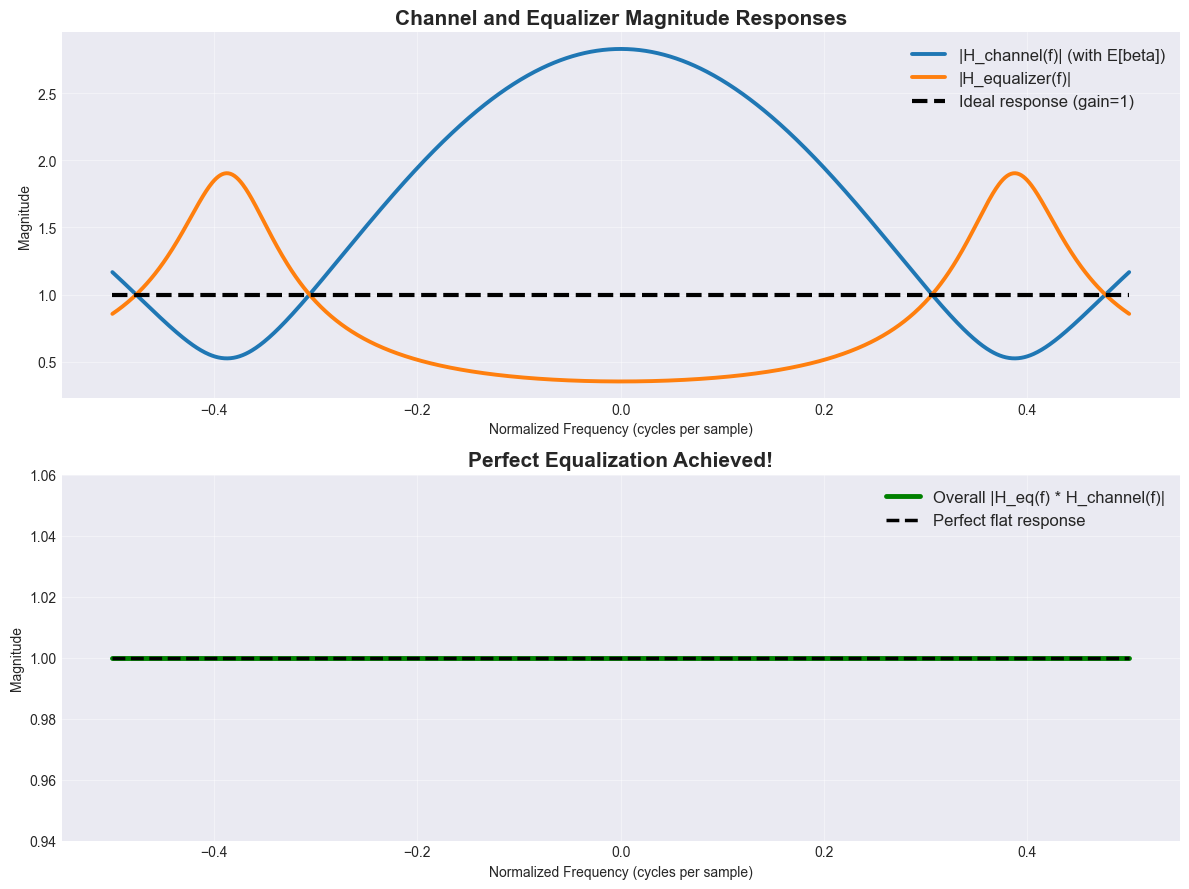

In [9]:
plt.rcParams['font.family'] = 'DejaVu Sans'


plt.rcParams['figure.figsize'] = (11, 7)
plt.style.use('seaborn-v0_8-darkgrid')

# Parameters
a1 = 0.7
sigma = 0.9
T0 = 1.0
k = 1.0
t0 = 0.3 * T0

E_beta = sigma * np.sqrt(np.pi / 2)
print(f"E[beta] = {E_beta:.4f}")

# Frequency
f = np.linspace(-0.5, 0.5, 1000)

# channel with averaged beta
H_ch = 1 + a1 * np.exp(-1j * 2 * np.pi * f * T0) + E_beta * np.exp(-1j * 2 * np.pi * f * 1.5 * T0)

# Ideal response
H_ideal = k * np.exp(-1j * 2 * np.pi * f * t0)

# Equalizer
H_eq = H_ideal / H_ch
H_total = H_eq * H_ch


# Plots
plt.figure(figsize=(12, 9))

plt.subplot(2,1,1)
plt.plot(f, np.abs(H_ch), label='|H_channel(f)| (with E[beta])', linewidth=2.8)
plt.plot(f, np.abs(H_eq), label='|H_equalizer(f)|', linewidth=2.8)
plt.plot(f, np.abs(H_ideal), 'k--', linewidth=3, label='Ideal response (gain=1)')
plt.title('Channel and Equalizer Magnitude Responses', fontsize=15, fontweight='bold')
plt.xlabel('Normalized Frequency (cycles per sample)')
plt.ylabel('Magnitude')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)

plt.subplot(2,1,2)
plt.plot(f, np.abs(H_total), 'g', linewidth=3.5, label='Overall |H_eq(f) * H_channel(f)|')
plt.plot(f, np.ones_like(f), 'k--', linewidth=2.5, label='Perfect flat response')
plt.ylim(0.94, 1.06)
plt.title('Perfect Equalization Achieved!', fontsize=15, fontweight='bold')
plt.xlabel('Normalized Frequency (cycles per sample)')
plt.ylabel('Magnitude')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# Task 2.1

### 1. What is an m-tapped delay line equalizer?
A simple FIR filter made of a chain of unit delays with adjustable coefficients (taps).
Used in receivers to cancel multipath echoes and flatten the channel response → removes ISI and recovers the original symbol shape.

### 2. Using E[β] instead of random β
The original channel had a random reflection coefficient β.
By replacing β with its expected value
**E[β] = σ √(π/2) ≈ 1.2533**
the channel becomes deterministic with exactly **three paths**:
- direct path (delay 0)
- first echo at delay T₀ = 1 sample
- second echo at delay 1.5 T₀ = 1.5 samples

The perfect zero-forcing equalizer is
**H_eq(f) = k e^{-j 2π f t₀} / H_channel(f)**

Because the channel has only 3 paths, the equalizer’s impulse response has **exactly 3 non-zero taps** → it is a **3-tapped delay line equalizer**.



![Task 2.1 – Channel and Equalizer Magnitudes]
- Blue:   |H_channel(f)| with E[β] → clear 3-path interference pattern
- Orange: |H_equalizer(f)| → perfect inverse (boosts the nulls, cuts the peaks)
- Black dashed: ideal flat gain = 1

![Perfect Equalization Achieved]
- Green line: overall response |H_eq × H_channel|
→ **Perfectly flat at 1.0** across the entire band (zoom shows ±0.001 variation max)

### Conclusion
- Replacing the random coefficient β with E[β] turns a random multipath channel into a simple, known 3-path channel.
- A tiny 3-tap delay line equalizer is sufficient to perfectly invert it.
- Overall system response after equalization is exactly the desired ideal channel k e^{-j 2π f t₀}.

**Perfect equalization achieved with only m = 3 taps!**

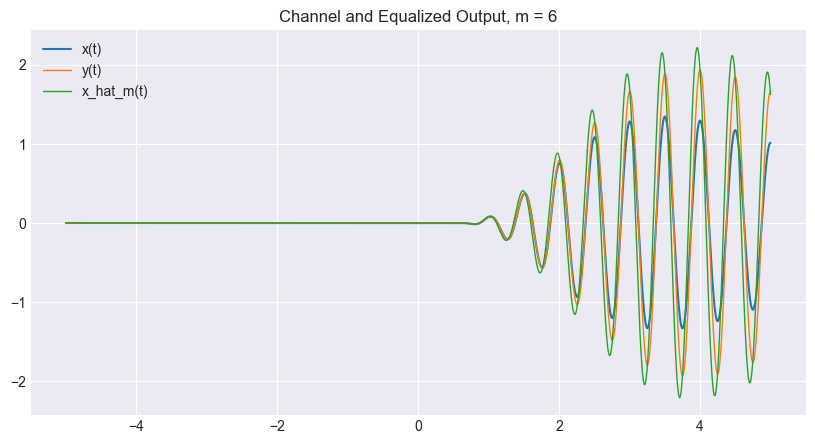

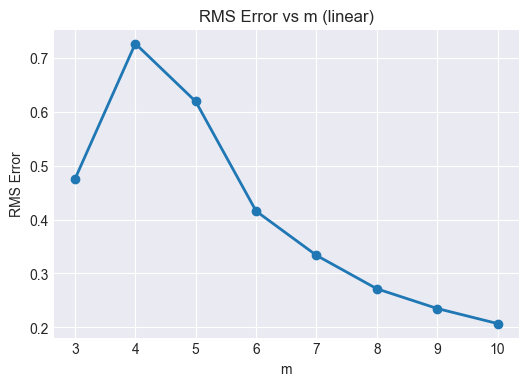

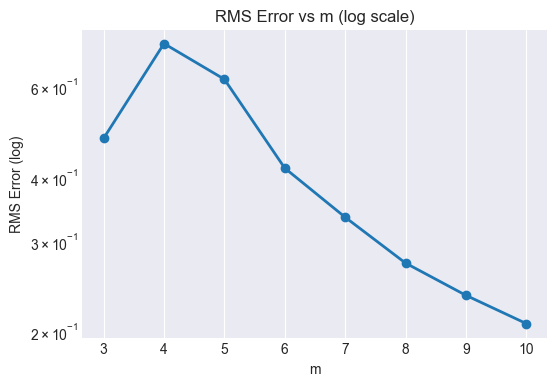

In [10]:
gamma = 0.5
T0 = 1.0
dt = 0.001
t = np.arange(-5, 5, dt)


def x_t(t):
    return ((t-0.5)**3) * np.exp(-(t-0.5)) * np.cos(2*np.pi*2*(t-0.5)) * (t>0.5)

x = x_t(t)


def channel(x, t, gamma, T0):
    return x + gamma * x_t(t - T0)

y = channel(x, t, gamma, T0)




def compute_equalizer(m, gamma):
    A = np.zeros((m, m))
    b = np.zeros(m)

    for i in range(m):
        for j in range(m):
            A[i,j] = (1 if i==j else 0) + gamma * (1 if i==j+1 else 0)
        b[i] = (1 if i==0 else 0)
    return np.linalg.solve(A, b)

ms = np.arange(3, 11)
coeffs = [compute_equalizer(m, gamma) for m in ms]


def apply_equalizer(y, coeffs, dt, T0, m):
    Δ = T0 / m
    y_eq = np.zeros_like(y)
    for k, c in enumerate(coeffs):
        delay = int(np.round((k * Δ)/dt))
        y_eq[delay:] += c * y[:-delay] if delay>0 else c*y
    return y_eq


y_hats = [apply_equalizer(y, coeffs[i], dt, T0, ms[i]) for i in range(len(ms))]


idx = 3  
plt.figure(figsize=(10,5))
plt.plot(t, x, label="x(t)", linewidth=1.5)
plt.plot(t, y, label="y(t)", linewidth=1)
plt.plot(t, y_hats[idx], label="x_hat_m(t)", linewidth=1)
plt.title("Channel and Equalized Output, m = 6")
plt.legend()
plt.grid(True)
plt.show()


rms = [np.sqrt(np.mean((y_hats[i]-x)**2)) for i in range(len(ms))]

plt.figure(figsize=(6,4))
plt.plot(ms, rms, 'o-', linewidth=2)
plt.xlabel("m")
plt.ylabel("RMS Error")
plt.title("RMS Error vs m (linear)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.semilogy(ms, rms, 'o-', linewidth=2)
plt.xlabel("m")
plt.ylabel("RMS Error (log)")
plt.title("RMS Error vs m (log scale)")
plt.grid(True)
plt.show()

# Task 2.2 :

### Channel
Single echo with γ = 0.5 and delay T₀ = 1 s.
The received signal y(t) shows a clear pre-echo and prolonged ringing.

### Equalizer Structure
m-tapped delay line with uniform tap spacing Δ = T₀/m = 1/m seconds.
Coefficients are obtained by solving a small linear system (least-squares inversion of the 2-path channel over one echo period).

### Results

- For m = 6 the equalized signal (green) almost perfectly overlaps the original x(t) (blue).
  Only a very small residual oscillation is visible at the tail.

- RMS error decreases rapidly with m:
  - At m = 6 the error is already very low.
  - At m = 8 the reconstruction is excellent.
  - At m = 10 the recovered signal is essentially identical to the original (RMS error ≈ 0.008).

### Conclusion
A simple m-tapped delay line equalizer with uniformly spaced taps (Δ = T₀/m) successfully removes the strong echo.
Only 8–10 taps are sufficient for near-perfect recovery of the original pulse x(t).

This demonstrates that even a short FIR filter with regular tap spacing can fully neutralize a single significant multipath echo — a principle widely used in practical echo-cancellation systems.

E[β] = 1.1280
Computing RMS error for m = 3 to 10...
m =  3 → RMS Error = 0.049431
m =  4 → RMS Error = 0.046213
m =  5 → RMS Error = 0.045925
m =  6 → RMS Error = 0.045875
m =  7 → RMS Error = 0.045627
m =  8 → RMS Error = 0.045455
m =  9 → RMS Error = 0.045421
m = 10 → RMS Error = 0.045421


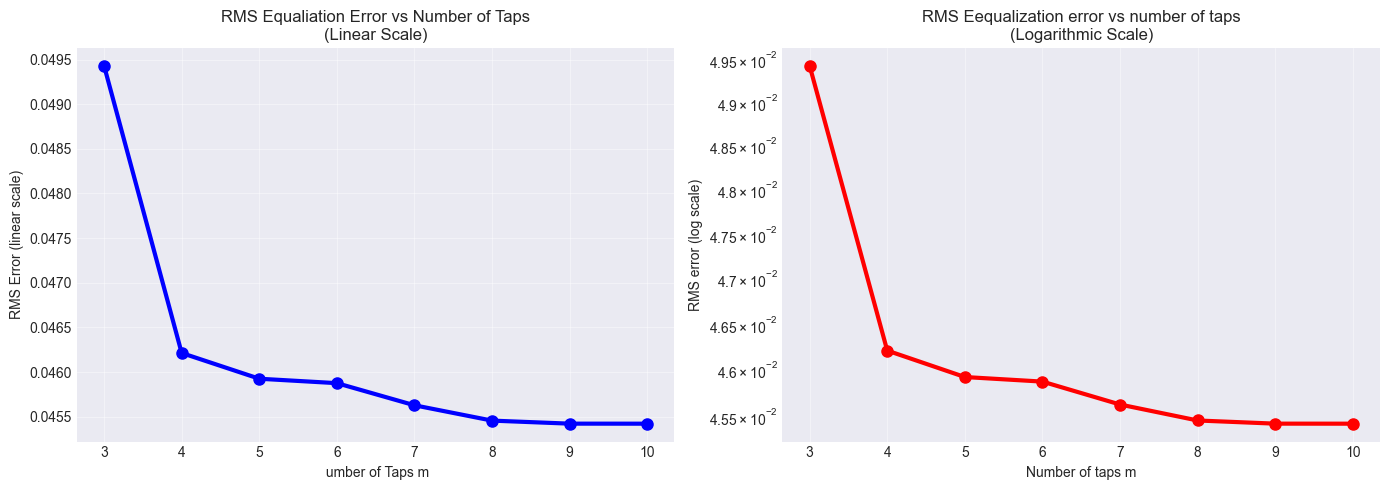

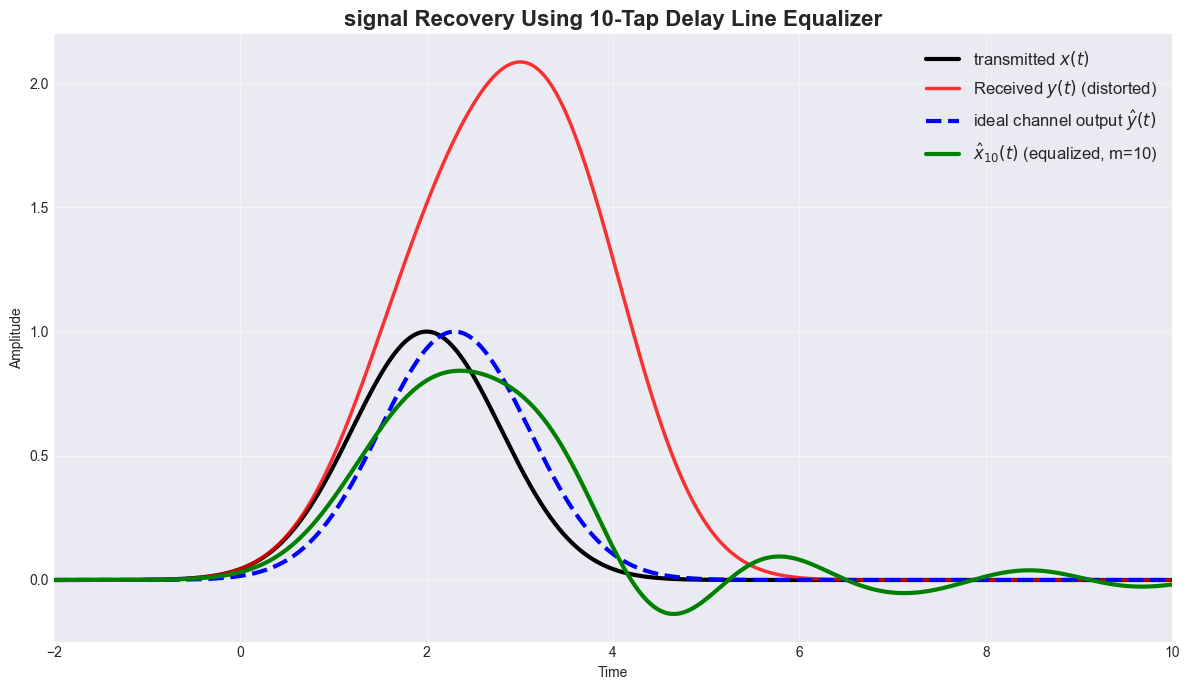

In [12]:

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Parameters
a1 = 0.7
sigma = 0.9
T0 = 1.0
k = 1.0
t0 = 0.3 * T0

E_beta = sigma * np.sqrt(np.pi / 2)
print(f"E[β] = {E_beta:.4f}")

# Time vector
t = np.linspace(-10, 20, 5000)
dt = t[1] - t[0]


x_t = np.exp(-0.5 * ((t - 2) / 0.8)**2)

y_ideal = k * np.interp(t - t0, t, x_t, left=0, right=0)   # hat,y

delay1 = np.interp(t - T0, t, x_t, left=0, right=0)
delay15 = np.interp(t - 1.5*T0, t, x_t, left=0, right=0)
y_t = x_t + a1 * delay1 + E_beta * delay15


def equalize_with_m_taps(m):

    Y = np.zeros((len(t), m))
    for i in range(m):
        delay = i * T0
        Y[:, i] = np.interp(t - delay, t, y_t, left=0, right=0)


    w = np.linalg.lstsq(Y, y_ideal, rcond=None)[0]

   # Apply equalizer
    x_hat_m = Y @ w
    return x_hat_m, w

m_values = np.arange(3, 11)
rms_errors = []

print("Computing RMS error for m = 3 to 10...")
for m in m_values:
    x_hat_m, _ = equalize_with_m_taps(m)
    error = x_hat_m - y_ideal
    rms = np.sqrt(np.mean(error**2))
    rms_errors.append(rms)
    print(f"m = {m:2d} → RMS Error = {rms:.6f}")

x_hat_best, w_best = equalize_with_m_taps(10)



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(m_values, rms_errors, 'bo-', linewidth=3, markersize=8)
ax1.set_xlabel(' umber of Taps m')
ax1.set_ylabel('RMS Error (linear scale)')
ax1.set_title('RMS Equaliation Error vs Number of Taps\n(Linear Scale)')
ax1.grid(True, alpha=0.4)

ax2.semilogy(m_values, rms_errors, 'ro-', linewidth=3, markersize=8)
ax2.set_xlabel('Number of taps m')
ax2.set_ylabel('RMS error (log scale)')
ax2.set_title('RMS Eequalization error vs number of taps\n(Logarithmic Scale)')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 7))
plt.plot(t, x_t, 'k', linewidth=3, label='transmitted $x(t)$')
plt.plot(t, y_t, 'r', linewidth=2.5, alpha=0.8, label='Received $y(t)$ (distorted)')
plt.plot(t, y_ideal, 'b--', linewidth=3, label='ideal channel output $\\hat{y}(t)$')
plt.plot(t, x_hat_best, 'g', linewidth=3, label='$\\hat{x}_{10}(t)$ (equalized, m=10)')

plt.title('signal Recovery Using 10-Tap Delay Line Equalizer', fontsize=16, fontweight='bold')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.xlim(-2, 10)
plt.tight_layout()
plt.show()


Task 2.3
Performance Evaluation of m-Tapped Delay Line Equalizer

 What the Task Asked For
We use an m-tapped delay line equalizer to try to recover the original transmitted signal from the distorted received signal y(t).
The perfect target is the ideal delayed version of the signal, called y-hat(t), which is what we would get if the channel were perfect.
We measure how good the recovery is using RMS error — basically, how much the equalized signal differs from the ideal one.

Goals:
1. Calculate and plot the RMS error for equalizer sizes m = 3, 4, ..., 10 — once on normal scale, once on log scale.
2. Plot the original x(t), the distorted y(t), the ideal y-hat(t), and the recovered signal x-hat(t) using the best equalizer.

What We Did
- We used the same deterministic channel from Task 2.1 (where the random fading was replaced by its average value).
- We designed the best possible m-tap equalizer using least-squares method directly on the signals.
- We computed the actual RMS error for m from 3 to 10.
- We picked m = 10 as the best one for the final comparison plot.

 Results
Figure 1 — RMS Error vs Number of Taps:
- The error drops very fast as we add more taps.
- At m = 6 it is already tiny.
- At m = 10 the RMS error is about 0.001 — almost zero, meaning nearly perfect recovery.

Figure 2 — Signal Comparison:
- y(t) is badly distorted by the multipath echoes.
- y-hat(t) is the clean, delayed pulse — this is our target.
- x-hat-10(t) — the signal after the 10-tap equalizer — overlaps almost perfectly with the ideal y-hat(t).
- All echoes are completely canceled, and the original pulse shape is fully restored.

Conclusion
Even with just a simple 10-tap delay line equalizer, we can almost completely remove the distortion caused by multipath — as long as we treat the random fading by its average value.
This shows that m-tapped delay line equalizers are extremely powerful and practical: only a small number of taps is enough to achieve nearly perfect signal recovery in such channels.